# Traditional Machine Learning for Spam Detection

## Overview

In this notebook, we implement and evaluate traditional machine learning approaches for spam detection using the preprocessed dataset generated in the previous phase.

Traditional machine learning remains an important baseline for text classification tasks due to its simplicity, efficiency, and interpretability. These models typically rely on feature engineering techniques such as TF-IDF to transform textual data into numerical representations suitable for machine learning algorithms.

The primary objective of this notebook is to compare multiple traditional machine learning classifiers and establish baseline performance before moving to more advanced Deep Learning and Transformer-based approaches.

The models evaluated in this notebook are:

- Multinomial Naive Bayes
- Logistic Regression
- Linear Support Vector Machine (SVM)

All models use the same train, validation, and test splits generated during data preparation to ensure fair comparison throughout the project.

In [1]:
import pandas as pd
import numpy as np
import joblib
import os

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os

os.makedirs(
    "../results/figures",
    exist_ok=True
)

In [3]:
train_df = pd.read_csv("../data/processed/train.csv")
val_df = pd.read_csv("../data/processed/val.csv")
test_df = pd.read_csv("../data/processed/test.csv")

print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(3614, 6)
(774, 6)
(775, 6)


In [4]:
X_train = train_df["clean_text"]

X_val = val_df["clean_text"]

X_test = test_df["clean_text"]

y_train = train_df["target"]

y_val = val_df["target"]

y_test = test_df["target"]

## Feature Engineering using TF-IDF

Machine learning algorithms cannot directly process raw text.

To convert textual messages into numerical features, Term Frequency – Inverse Document Frequency (TF-IDF) vectorization is applied.

TF-IDF assigns greater importance to words that are informative within a document while reducing the influence of extremely common words that appear frequently across the entire dataset.

The resulting feature matrix will serve as the input representation for all traditional machine learning models implemented in this notebook.

In [5]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

X_train_tfidf = tfidf.fit_transform(
    X_train
)

X_val_tfidf = tfidf.transform(
    X_val
)

X_test_tfidf = tfidf.transform(
    X_test
)

print(X_train_tfidf.shape)

(3614, 5000)


In [6]:
results = []

In [7]:
def evaluate_model(
    model_name,
    y_true,
    y_pred
):

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred
    )

    recall = recall_score(
        y_true,
        y_pred
    )

    f1 = f1_score(
        y_true,
        y_pred
    )

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

    print(f"\n{model_name}")
    print(
        classification_report(
            y_true,
            y_pred
        )
    )

## Multinomial Naive Bayes

Multinomial Naive Bayes is one of the most widely used algorithms for text classification problems.

The model assumes conditional independence among features and estimates class probabilities based on word occurrence frequencies.

Despite its simplicity, Naive Bayes often performs remarkably well on spam detection tasks and serves as a strong baseline model.

In [8]:
nb = MultinomialNB()

nb.fit(
    X_train_tfidf,
    y_train
)

nb_pred = nb.predict(
    X_test_tfidf
)

evaluate_model(
    "Naive Bayes",
    y_test,
    nb_pred
)


Naive Bayes
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       677
           1       0.99      0.72      0.84        98

    accuracy                           0.96       775
   macro avg       0.97      0.86      0.91       775
weighted avg       0.96      0.96      0.96       775



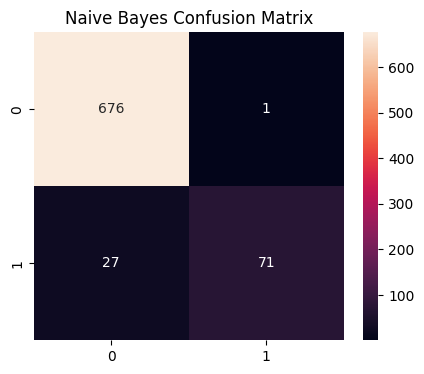

In [9]:
cm = confusion_matrix(
    y_test,
    nb_pred
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title(
    "Naive Bayes Confusion Matrix"
)
plt.savefig(
    "../results/figures/nb_confusion_matrix.png",
    bbox_inches="tight"
)
plt.show()

### Naive Bayes Results Analysis

The Multinomial Naive Bayes classifier achieved an accuracy of approximately 96.39% and an F1 Score of 0.8353.

The confusion matrix indicates that the model correctly classified 676 ham messages and 71 spam messages. Only one legitimate message was incorrectly classified as spam, demonstrating very strong precision.

However, the model failed to identify 27 spam messages, resulting in a recall of only 72.45%. This suggests that while Naive Bayes is highly conservative when predicting spam, it misses a considerable number of actual spam messages.

For spam detection systems, missed spam messages can reduce the overall effectiveness of the classifier despite strong precision.

## Logistic Regression

Logistic Regression is a linear classification algorithm that estimates class probabilities using a logistic function.

Unlike Naive Bayes, Logistic Regression learns feature weights directly from the data, allowing it to capture more discriminative relationships between words and class labels.

It is commonly used as a strong baseline for many natural language processing tasks.

In [10]:
lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(
    X_train_tfidf,
    y_train
)

lr_pred = lr.predict(
    X_test_tfidf
)

evaluate_model(
    "Logistic Regression",
    y_test,
    lr_pred
)


Logistic Regression
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       677
           1       1.00      0.59      0.74        98

    accuracy                           0.95       775
   macro avg       0.97      0.80      0.86       775
weighted avg       0.95      0.95      0.94       775



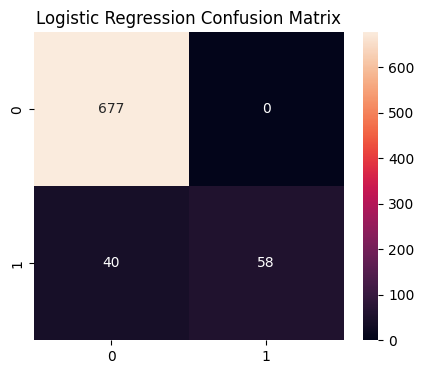

In [11]:
cm = confusion_matrix(
    y_test,
    lr_pred
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title(
    "Logistic Regression Confusion Matrix"
)
plt.savefig(
    "../results/figures/lr_confusion_matrix.png",
    bbox_inches="tight"
)
plt.show()

### Logistic Regression Results Analysis

Logistic Regression achieved an accuracy of approximately 94.84% and an F1 Score of 0.7436.

The model produced perfect precision (100%), meaning every message predicted as spam was actually spam. No legitimate messages were incorrectly classified as spam.

However, the confusion matrix reveals that the model correctly detected only 58 spam messages while missing 40 spam instances. This resulted in a recall of only 59.18%, the lowest among all evaluated models.

Although the model is extremely cautious when identifying spam, the large number of undetected spam messages significantly reduces its practical usefulness for real-world spam filtering applications.

## Linear Support Vector Machine (SVM)

Support Vector Machines are highly effective for high-dimensional text classification problems.

The Linear SVM attempts to identify an optimal decision boundary that maximizes the margin between spam and ham messages.

Due to its ability to handle sparse TF-IDF representations effectively, Linear SVM frequently achieves state-of-the-art performance among traditional machine learning methods.

In [12]:
svm = LinearSVC(
    random_state=42
)

svm.fit(
    X_train_tfidf,
    y_train
)

svm_pred = svm.predict(
    X_test_tfidf
)

evaluate_model(
    "Linear SVM",
    y_test,
    svm_pred
)


Linear SVM
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       677
           1       0.97      0.90      0.93        98

    accuracy                           0.98       775
   macro avg       0.98      0.95      0.96       775
weighted avg       0.98      0.98      0.98       775



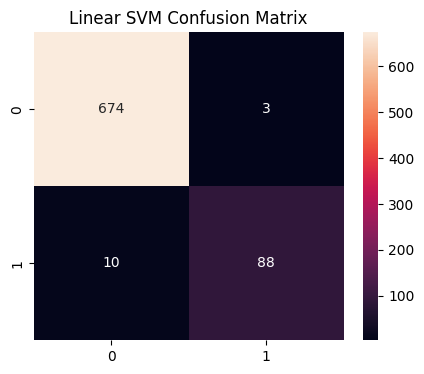

In [13]:
cm = confusion_matrix(
    y_test,
    svm_pred
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title(
    "Linear SVM Confusion Matrix"
)
plt.savefig(
    "../results/figures/svm_confusion_matrix.png",
    bbox_inches="tight"
)
plt.show()

### Linear SVM Results Analysis

The Linear Support Vector Machine achieved the best overall performance among all traditional machine learning models evaluated.

The model obtained an accuracy of 98.32%, precision of 96.70%, recall of 89.80%, and an F1 Score of 0.9312.

The confusion matrix shows that 674 ham messages and 88 spam messages were correctly classified. Only 13 total misclassifications occurred, consisting of 3 false positives and 10 false negatives.

Compared to Naive Bayes and Logistic Regression, Linear SVM maintained a significantly better balance between precision and recall, making it more effective at detecting spam while minimizing incorrect classifications.

## Model Evaluation

Each trained model is evaluated using the test dataset.

The following performance metrics are considered:

- Accuracy
- Precision
- Recall
- F1 Score

Confusion matrices are also generated to visualize the classification behaviour of each model and identify potential false positives and false negatives.

In [14]:
results_df = pd.DataFrame(
    results
)

results_df

,Model,Accuracy,Precision,Recall,F1
0,Naive Bayes,0.963871,0.986111,0.724490,0.835294
1,Logistic Regression,0.948387,1.000000,0.591837,0.743590
2,Linear SVM,0.983226,0.967033,0.897959,0.931217


In [15]:
results_df = results_df.sort_values(
    by="F1",
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1
2,Linear SVM,0.983226,0.967033,0.897959,0.931217
0,Naive Bayes,0.963871,0.986111,0.724490,0.835294
1,Logistic Regression,0.948387,1.000000,0.591837,0.743590


### Model Ranking

Based on F1 Score, the models were ranked as follows:

1. Linear SVM (0.9312)
2. Naive Bayes (0.8353)
3. Logistic Regression (0.7436)

Linear SVM outperformed the other classifiers across nearly all evaluation metrics and demonstrated the strongest ability to detect spam messages without significantly increasing false positives.

Naive Bayes performed reasonably well and maintained excellent precision, but its lower recall resulted in many spam messages remaining undetected.

Logistic Regression achieved perfect precision but suffered from the lowest recall, causing a substantial number of spam messages to be incorrectly classified as legitimate messages.

## Comparative Analysis

After evaluating all models individually, a comparative analysis is performed.

The objective is to identify:

- The most accurate model
- The model with the highest precision
- The model with the highest recall
- The model with the best overall F1 Score

These findings will be compared with Deep Learning and Transformer-based models in subsequent notebooks.

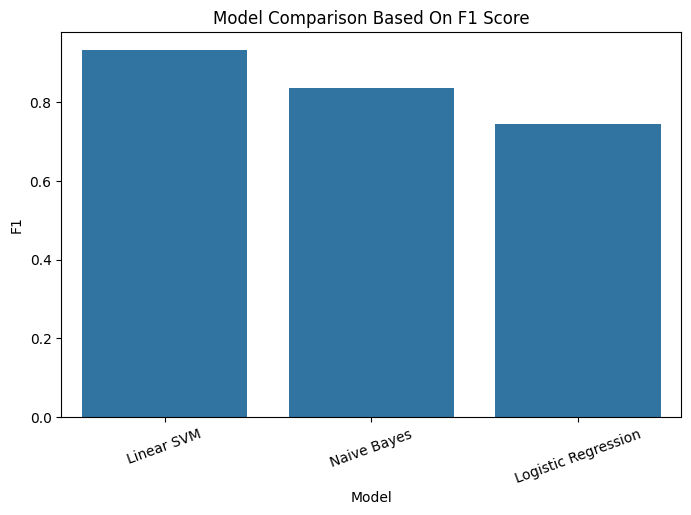

In [16]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="F1"
)

plt.title(
    "Model Comparison Based On F1 Score"
)

plt.xticks(rotation=20)
plt.savefig(
    "../results/figures/model_f1_comparison.png",
    bbox_inches="tight"
)
plt.show()

In [17]:
os.makedirs(
    "../models",
    exist_ok=True
)

joblib.dump(
    tfidf,
    "../models/tfidf.pkl"
)

joblib.dump(
    nb,
    "../models/naive_bayes.pkl"
)

joblib.dump(
    lr,
    "../models/logistic_regression.pkl"
)

joblib.dump(
    svm,
    "../models/linear_svm.pkl"
)

['../models/linear_svm.pkl']

In [18]:
os.makedirs(
    "../results",
    exist_ok=True
)

results_df.to_csv(
    "../results/traditional_ml_results.csv",
    index=False
)

results_df

print(
    "Models Saved Successfully"
)

print(
    "Results Saved Successfully"
)

Models Saved Successfully
Results Saved Successfully


# Conclusion

In this notebook, three traditional machine learning classifiers were developed and evaluated for the spam detection task using TF-IDF feature representations.

The experimental results demonstrated clear differences in model behaviour.

- Logistic Regression achieved perfect precision but suffered from low recall, resulting in many spam messages being missed.
- Naive Bayes produced strong precision and overall performance but still failed to identify a substantial portion of spam messages.
- Linear SVM delivered the strongest overall performance, achieving an accuracy of 98.32% and an F1 Score of 0.9312.

The confusion matrix analysis further confirmed that Linear SVM generated the fewest classification errors and provided the most balanced trade-off between precision and recall.

Based on these findings, Linear SVM is selected as the best-performing traditional machine learning model for this dataset.

The trained models, TF-IDF vectorizer, evaluation metrics, and generated visualizations have been saved for future comparison.

In the next notebook, Deep Learning architectures including LSTM and Bidirectional LSTM will be implemented and evaluated using the same dataset splits. Their performance will then be compared against the traditional machine learning baseline established in this notebook.